# Housing Cycle Risk (HCR) — Logit Regression

**Objective:**  
1. Reconstruct Malaysia Nominal Residential Price Index (level) from the available YoY % change series  
2. Apply Hodrick-Prescott (HP) filter (λ = 1600, quarterly standard) to decompose trend vs. cycle  
3. Create binary dependent variable: `cycle_pos = 1` if cyclical component > 0 (upward pressure), 0 otherwise  
4. Run logistic regression against macro/market independent variables  
5. Full diagnostics: pseudo-R², Hosmer-Lemeshow, ROC/AUC, VIF, confusion matrix

**Data sources (all from project property data folder):**
- `Time Series since 2001.xlsx` — HPI YoY, transaction volume, unsold stock, planned supply  
- `Quarterly_Impaired_Prop_Loan_Ratio_(98-25).xlsx` — loan delinquency proxy

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from statsmodels.tsa.filters.hp_filter import hpfilter
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from scipy import stats

# ── paths (repo-relative) ───────────────────────────────────────────────────────
def _find_repo_root(marker='property data', start=None):
    """Walk upward from the working dir until the data folder is found, so the
    notebook works whether it is launched from the repo root or Model Selection/."""
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, marker)):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise FileNotFoundError(f"Could not find '{marker}' above {os.getcwd()}")
        d = parent

REPO_ROOT = _find_repo_root()
PROP_DATA = os.path.join(REPO_ROOT, 'property data')
TS_FILE   = os.path.join(PROP_DATA, 'Time Series since 2001.xlsx')
IMP_FILE  = os.path.join(PROP_DATA, 'Quarterly_Impaired_Prop_Loan_Ratio_(98-25).xlsx')
BIS_FILE  = os.path.join(PROP_DATA, 'BIS_credittogdp.xlsx')

# figures saved to a "Code" folder at repo root (matches the savefig calls below)
os.makedirs(os.path.join(REPO_ROOT, 'Code'), exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})
print('Libraries loaded. PROP_DATA =', PROP_DATA)

Libraries loaded. PROP_DATA = c:\Users\User\Documents\APU\FYP2\property data


---
## 1. Reconstruct Mean House Price from YoY % Changes

**Method:**  
The raw data is Nominal Residential Price Index — Year-on-Year % change, quarterly (Q1 1989 – Q3 2025).  
We apply the chaining formula to recover a level series:

$$\text{Index}_t = \text{Index}_{t-4} \times \left(1 + \frac{\text{YoY}_t}{100}\right)$$

The first four quarters (Q1–Q4 1989) are initialised to 100 as a base.  
The index is then **anchored to actual RM values** using the known mean house price of **RM 498,590 at 2025 Q2**:

$$\text{Mean House Price}_t = \text{Index}_t \times \frac{498{,}590}{\text{Index}_{2025\text{Q2}}}$$

This back-calculates and forward-calculates the full RM price series from that single anchor point.

In [2]:
# ── load HPI YoY ───────────────────────────────────────────────────────────────
hp_raw = pd.read_excel(TS_FILE, sheet_name='House Price',
                       usecols=[0, 4], header=0)
hp_raw.columns = ['date', 'nominal_yoy']
hp_raw['date'] = pd.to_datetime(hp_raw['date'])
hp_raw = hp_raw.dropna(subset=['nominal_yoy']).sort_values('date').reset_index(drop=True)

print('HPI YoY series:')
print(f'  Observations : {len(hp_raw)}')
print(f'  Date range   : {hp_raw.date.min().strftime("%Y-Q%q"[:-2])} to {hp_raw.date.max().date()}')
print(f'  YoY range    : {hp_raw.nominal_yoy.min():.2f}% to {hp_raw.nominal_yoy.max():.2f}%')
hp_raw.head(8)

HPI YoY series:
  Observations : 147
  Date range   : 1989-Q to 2025-09-01
  YoY range    : -11.62% to 31.41%


,date,nominal_yoy
0,1989-03-01,6.3732
1,1989-06-01,6.1204
2,1989-09-01,2.9814
3,1989-12-01,1.6536
4,1990-03-01,1.5731
5,1990-06-01,1.1699
6,1990-09-01,1.6943
7,1990-12-01,11.7119


Anchor: 2025Q2 index level = 684.7499
Scale factor              = 728.1345
Verification 2025Q2       = RM 498,590

Mean House Price at selected periods:
  1989Q1: RM     72,813
  1995Q1: RM    135,516
  2000Q1: RM    150,543
  2005Q1: RM    176,839
  2010Q1: RM    209,489
  2015Q1: RM    345,269
  2020Q1: RM    430,401
  2025Q2: RM    498,590


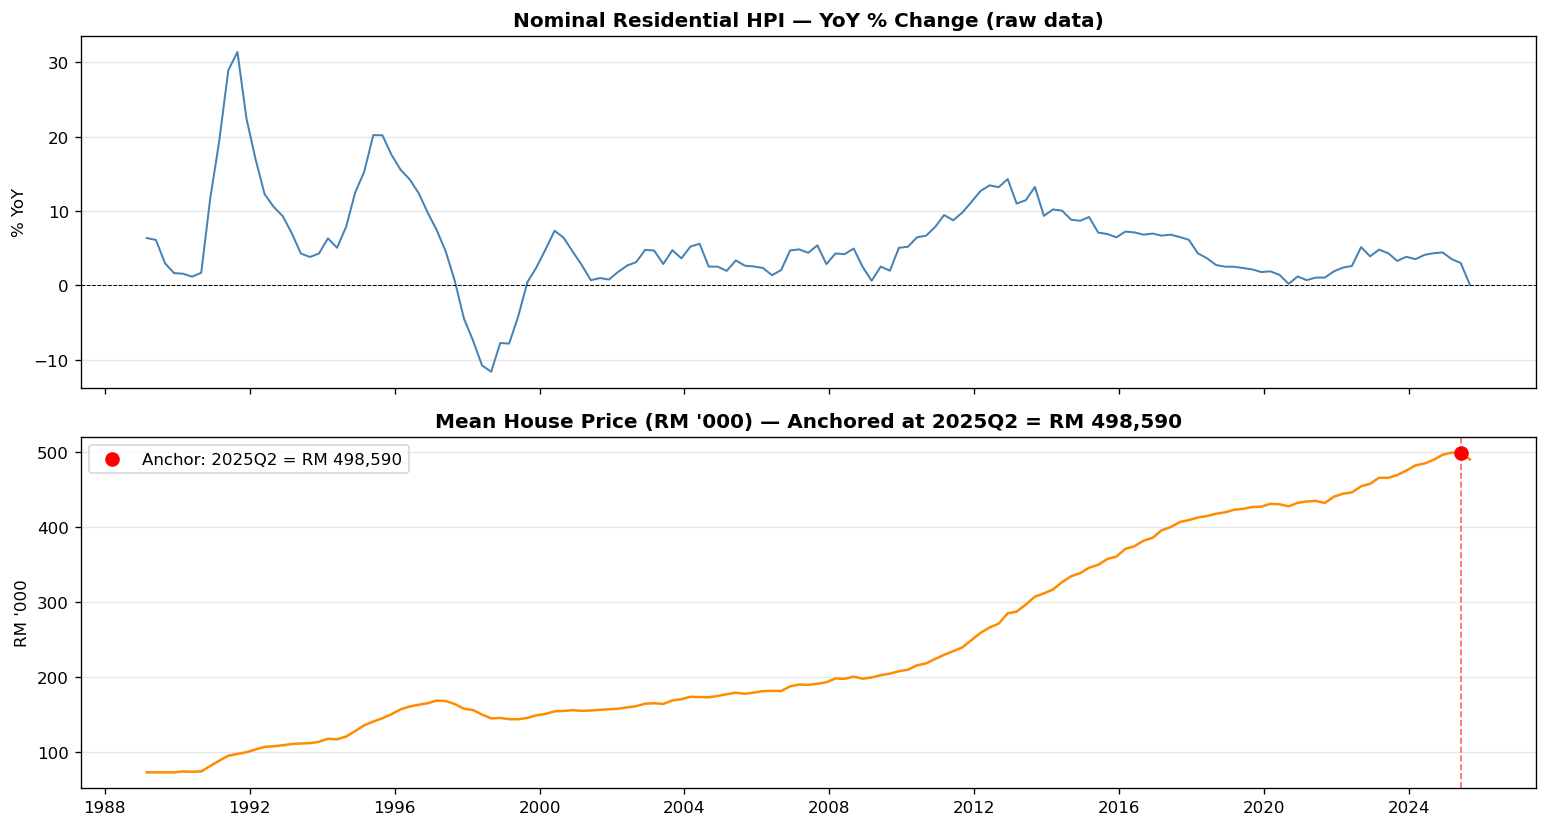

,date,nominal_yoy,mean_price
137,2023-06-01,4.3311,464921.841197
138,2023-09-01,3.2957,468654.846928
139,2023-12-01,3.8498,474624.714328
140,2024-03-01,3.5218,481481.076765
141,2024-06-01,4.1052,484007.812621
142,2024-09-01,4.3300,488947.601800
143,2024-12-01,4.4304,495652.487672
144,2025-03-01,3.5363,498507.692083
145,2025-06-01,3.0128,498590.000000
146,2025-09-01,0.0874,489374.942004


In [3]:
# ── reconstruct level index (base 100 at Q1-Q4 1989) ──────────────────────────
levels = np.full(len(hp_raw), np.nan)
levels[:4] = 100.0
for i in range(4, len(hp_raw)):
    levels[i] = levels[i - 4] * (1 + hp_raw.loc[i, 'nominal_yoy'] / 100)
hp_raw['hpi_level'] = levels

# ── anchor to 2025Q2 known mean house price = RM 498,590 ──────────────────────
ANCHOR_PRICE  = 498_590
ANCHOR_PERIOD = pd.Period('2025Q2')

anchor_idx_level = hp_raw.loc[
    hp_raw['date'].dt.to_period('Q') == ANCHOR_PERIOD, 'hpi_level'
].values[0]
scale_factor = ANCHOR_PRICE / anchor_idx_level
hp_raw['mean_price'] = hp_raw['hpi_level'] * scale_factor

print(f'Anchor: 2025Q2 index level = {anchor_idx_level:.4f}')
print(f'Scale factor              = {scale_factor:.4f}')
print(f'Verification 2025Q2       = RM {hp_raw.loc[hp_raw["date"].dt.to_period("Q")==ANCHOR_PERIOD,"mean_price"].values[0]:,.0f}')
print()
print('Mean House Price at selected periods:')
for p in ['1989Q1','1995Q1','2000Q1','2005Q1','2010Q1','2015Q1','2020Q1','2025Q2']:
    mask = hp_raw['date'].dt.to_period('Q') == pd.Period(p)
    if mask.any():
        print(f'  {p}: RM {hp_raw.loc[mask,"mean_price"].values[0]:>10,.0f}')

# ── plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(hp_raw['date'], hp_raw['nominal_yoy'], color='steelblue', linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=0.6, linestyle='--')
axes[0].set_title('Nominal Residential HPI — YoY % Change (raw data)', fontweight='bold')
axes[0].set_ylabel('% YoY')
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(hp_raw['date'], hp_raw['mean_price'] / 1_000, color='darkorange', linewidth=1.5)
axes[1].scatter([pd.Timestamp('2025-06-01')], [ANCHOR_PRICE / 1_000],
                color='red', s=60, zorder=5, label='Anchor: 2025Q2 = RM 498,590')
axes[1].axvline(pd.Timestamp('2025-06-01'), color='red', linewidth=1,
                linestyle='--', alpha=0.6)
axes[1].set_title("Mean House Price (RM '000) — Anchored at 2025Q2 = RM 498,590", fontweight='bold')
axes[1].set_ylabel("RM '000")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PROP_DATA.replace('property data', 'Code') + r'\hcr_01_mean_price.png',
            bbox_inches='tight')
plt.show()
hp_raw[['date','nominal_yoy','mean_price']].tail(10)

---
## 2. Hodrick-Prescott Filter on Mean House Price (λ = 1600)

Standard quarterly HP filter applied to the **Mean House Price (RM)** series.  
Decomposes into:
- **Trend** (τ): long-run price trajectory in RM  
- **Cyclical component** (c = Mean Price − τ): RM deviation from trend

**Dependent variable:**  
`cycle_pos = 1` if c > 0 (prices above trend → upward pressure), else 0

HP Filter on Mean House Price (RM):
  Cyclical component range : RM -13,315 to RM 16,982
  Periods cycle_pos = 1    : 78 / 147
  Periods cycle_pos = 0    : 69 / 147


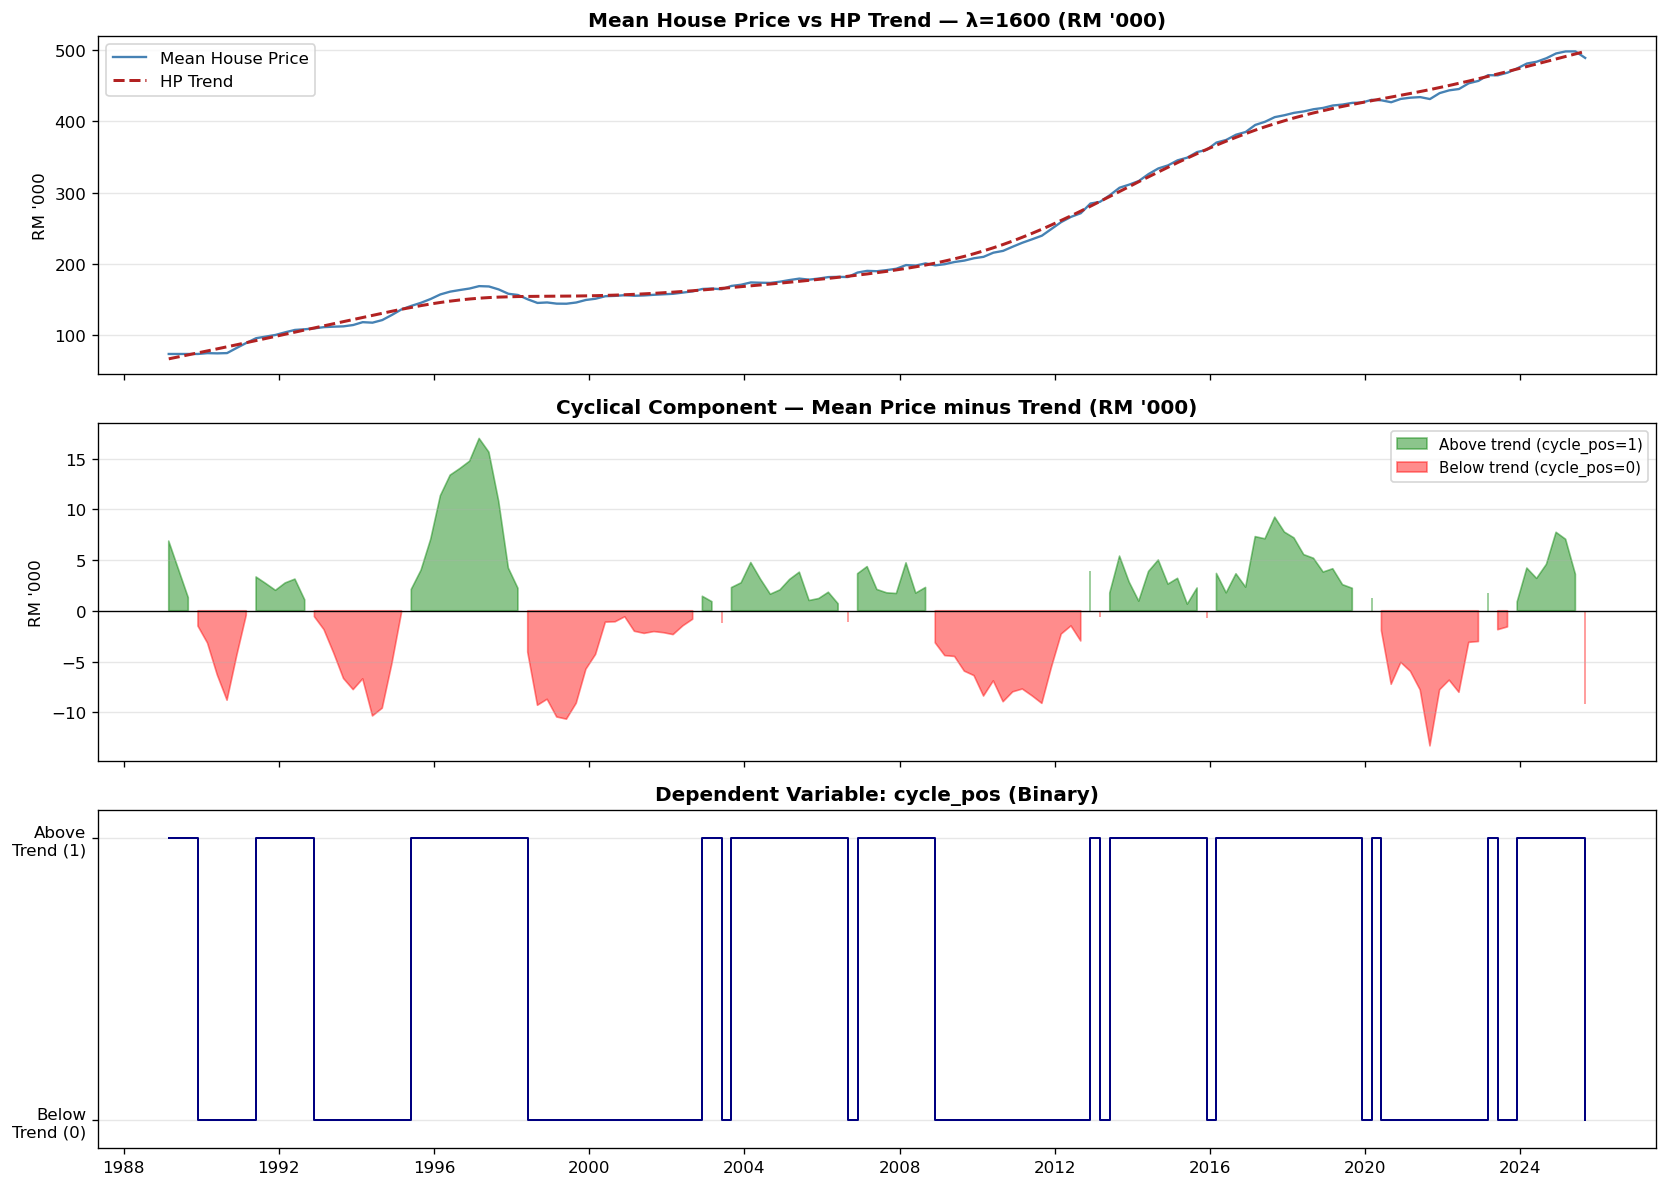

In [4]:
# ── HP filter applied to Mean House Price (RM) ────────────────────────────────
cycle, trend = hpfilter(hp_raw['mean_price'].values, lamb=1600)

hp_raw['mp_trend']  = trend
hp_raw['mp_cycle']  = cycle
hp_raw['cycle_pos'] = (hp_raw['mp_cycle'] > 0).astype(int)

print('HP Filter on Mean House Price (RM):')
print(f'  Cyclical component range : RM {cycle.min():,.0f} to RM {cycle.max():,.0f}')
print(f'  Periods cycle_pos = 1    : {hp_raw.cycle_pos.sum()} / {len(hp_raw)}')
print(f'  Periods cycle_pos = 0    : {(hp_raw.cycle_pos == 0).sum()} / {len(hp_raw)}')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(hp_raw['date'], hp_raw['mean_price'] / 1_000, color='steelblue',
             linewidth=1.4, label='Mean House Price')
axes[0].plot(hp_raw['date'], hp_raw['mp_trend'] / 1_000, color='firebrick',
             linewidth=1.8, linestyle='--', label='HP Trend')
axes[0].set_title("Mean House Price vs HP Trend — λ=1600 (RM '000)", fontweight='bold')
axes[0].set_ylabel("RM '000")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].fill_between(hp_raw['date'], hp_raw['mp_cycle'] / 1_000, 0,
                     where=(hp_raw['mp_cycle'] > 0), color='green', alpha=0.45,
                     label='Above trend (cycle_pos=1)')
axes[1].fill_between(hp_raw['date'], hp_raw['mp_cycle'] / 1_000, 0,
                     where=(hp_raw['mp_cycle'] <= 0), color='red', alpha=0.45,
                     label='Below trend (cycle_pos=0)')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title("Cyclical Component — Mean Price minus Trend (RM '000)", fontweight='bold')
axes[1].set_ylabel("RM '000")
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

axes[2].step(hp_raw['date'], hp_raw['cycle_pos'], color='navy',
             linewidth=1.2, where='post')
axes[2].set_ylim(-0.1, 1.1)
axes[2].set_yticks([0, 1])
axes[2].set_yticklabels(['Below\nTrend (0)', 'Above\nTrend (1)'])
axes[2].set_title('Dependent Variable: cycle_pos (Binary)', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PROP_DATA.replace('property data', 'Code') + r'\hcr_02_hp_filter.png',
            bbox_inches='tight')
plt.show()

---
## 3. Load Independent Variables

| Variable | Source | Entered as | Rationale |
|---|---|---|---|
| `sales_vol_yoy` | RP_Prop_Sales | YoY % growth | Removes trend; captures demand momentum |
| `unsold_co` | Unsold sheet | Level (units) | Overhang stock; level is meaningful |
| `unsold_uc` | Unsold sheet | Level (units) | Pipeline stock; level is meaningful |
| `planned_supply_yoy` | Supply sheet | YoY % growth | Removes trend; captures supply pipeline change |
| `impaired_ratio` | Impaired Loans xlsx | Level (%) | Already a ratio; stationary |
| `credit_gdp_yoy` | BIS_credittogdp xlsx | YoY growth (pp) | Credit expansion cycle; r = −0.27 with cycle_pos |

In [5]:
# ── 3a. Transaction Volume ─────────────────────────────────────────────────────
sales = pd.read_excel(TS_FILE, sheet_name='RP_Prop_Sales', usecols=[0, 1], header=0)
sales.columns = ['date', 'sales_vol']
sales['date'] = pd.to_datetime(sales['date'])
sales = sales.dropna().sort_values('date').reset_index(drop=True)
print(f'Sales volume   : {len(sales)} obs, {sales.date.min().date()} to {sales.date.max().date()}')

# ── 3b. Unsold stock ───────────────────────────────────────────────────────────
unsold_raw = pd.read_excel(TS_FILE, sheet_name='Unsold', header=0)

uc_df = unsold_raw.iloc[:, [0, 1]].copy()
uc_df.columns = ['date', 'unsold_uc']
uc_df['date'] = pd.to_datetime(uc_df['date'], errors='coerce')
uc_df = uc_df.dropna().sort_values('date').reset_index(drop=True)

un_df = unsold_raw.iloc[:, [3, 4]].copy()
un_df.columns = ['date', 'unsold_total']
un_df['date'] = pd.to_datetime(un_df['date'], errors='coerce')
un_df = un_df.dropna().sort_values('date').reset_index(drop=True)

co_df = unsold_raw.iloc[:, [6, 7]].copy()
co_df.columns = ['date', 'unsold_co']
co_df['date'] = pd.to_datetime(co_df['date'], errors='coerce')
co_df = co_df.dropna().sort_values('date').reset_index(drop=True)

print(f'Unsold UC      : {len(uc_df)} obs, {uc_df.date.min().date()} to {uc_df.date.max().date()}')
print(f'Unsold CO      : {len(co_df)} obs, {co_df.date.min().date()} to {co_df.date.max().date()}')

# ── 3c. Planned Supply ─────────────────────────────────────────────────────────
supply = pd.read_excel(TS_FILE, sheet_name='Supply', usecols=[0, 1], header=0)
supply.columns = ['date', 'planned_supply']
supply['date'] = pd.to_datetime(supply['date'])
supply = supply.dropna().sort_values('date').reset_index(drop=True)
print(f'Planned supply : {len(supply)} obs, {supply.date.min().date()} to {supply.date.max().date()}')

# ── 3d. Impaired Loan Ratio ────────────────────────────────────────────────────
def parse_qqyy(s):
    """Convert '1Q98' → Timestamp for Q1 1998."""
    q_map = {'1': '01', '2': '04', '3': '07', '4': '10'}
    q, yr = str(s)[0], str(s)[2:]
    yr_full = '19' + yr if int(yr) >= 50 else '20' + yr
    return pd.Timestamp(f'{yr_full}-{q_map[q]}-01')

imp = pd.read_excel(IMP_FILE, header=0)
imp.columns = ['date_str', 'impaired_ratio']
imp['date'] = imp['date_str'].apply(parse_qqyy)
imp = imp[['date', 'impaired_ratio']].sort_values('date').reset_index(drop=True)
print(f'Impaired ratio : {len(imp)} obs, {imp.date.min().date()} to {imp.date.max().date()}')

# ── 3e. BIS Credit-to-GDP ──────────────────────────────────────────────────────
bis = pd.read_excel(BIS_FILE, sheet_name='Quarterly, End of Quarter', header=0)
bis.columns = ['date', 'credit_gdp']
bis['date'] = pd.to_datetime(bis['date'])
bis = bis.dropna().sort_values('date').reset_index(drop=True)
print(f'Credit/GDP     : {len(bis)} obs, {bis.date.min().date()} to {bis.date.max().date()}'
      f'  (range {bis.credit_gdp.min():.1f}–{bis.credit_gdp.max():.1f}%)')

Sales volume   : 95 obs, 2002-03-01 to 2025-09-01
Unsold UC      : 91 obs, 2003-03-01 to 2025-09-01
Unsold CO      : 94 obs, 2002-06-01 to 2025-09-01
Planned supply : 102 obs, 2000-06-01 to 2025-09-01
Impaired ratio : 112 obs, 1998-01-01 to 2025-10-01
Credit/GDP     : 103 obs, 2000-01-01 to 2025-07-01  (range 131.2–182.9%)


---
## 4. Merge All Series

Merge on date (quarterly). The overlapping window of **all** series determines the regression sample.

In [6]:
# ── dependent variable subset ─────────────────────────────────────────────────
dep = hp_raw[['date', 'mean_price', 'mp_trend', 'mp_cycle', 'cycle_pos']].copy()

# ── normalise all dates to pandas quarterly Period then back to Timestamp ──────
def to_quarter_ts(df_in, date_col='date'):
    df_out = df_in.copy()
    df_out[date_col] = df_out[date_col].dt.to_period('Q').dt.to_timestamp()
    return df_out

dep    = to_quarter_ts(dep)
sales  = to_quarter_ts(sales)
co_df  = to_quarter_ts(co_df)
uc_df  = to_quarter_ts(uc_df)
supply = to_quarter_ts(supply)
imp    = to_quarter_ts(imp)
bis    = to_quarter_ts(bis)

# ── sequential left-join ───────────────────────────────────────────────────────
df = dep.copy()
for right, name in [
    (sales,   'sales_vol'),
    (co_df,   'unsold_co'),
    (uc_df,   'unsold_uc'),
    (supply,  'planned_supply'),
    (imp,     'impaired_ratio'),
    (bis,     'credit_gdp'),
]:
    df = df.merge(right[['date', name]], on='date', how='left')

# ── YoY % growth transformations (4-period lag = same quarter prior year) ─────
df['sales_vol_yoy']      = df['sales_vol'].pct_change(4) * 100
df['planned_supply_yoy'] = df['planned_supply'].pct_change(4) * 100
df['credit_gdp_yoy']     = df['credit_gdp'].pct_change(4) * 100

# ── final model dataset ────────────────────────────────────────────────────────
# unsold_total dropped (VIF > 40 — linear combo of unsold_co + unsold_uc)
indep_cols = ['sales_vol_yoy', 'unsold_co', 'unsold_uc',
              'planned_supply_yoy', 'impaired_ratio', 'credit_gdp_yoy']
df_model = df.dropna(subset=indep_cols + ['cycle_pos']).reset_index(drop=True)

print('Merged dataset (full):  ', df.shape)
print('Model-ready (no NaN):   ', df_model.shape)
print(f'Sample window: {df_model.date.min().date()} to {df_model.date.max().date()}')
print()
print('Class balance of cycle_pos:')
print(df_model['cycle_pos'].value_counts().to_string())
df_model[indep_cols + ['cycle_pos']].describe().round(2)

Merged dataset (full):   (147, 14)
Model-ready (no NaN):    (91, 14)
Sample window: 2003-01-01 to 2025-07-01

Class balance of cycle_pos:
cycle_pos
1    56
0    35


,sales_vol_yoy,unsold_co,unsold_uc,planned_supply_yoy,impaired_ratio,credit_gdp_yoy,cycle_pos
count,91.00,91.00,91.00,91.00,91.00,91.00,91.00
mean,3.09,21382.34,57887.23,-1.13,2.82,-0.39,0.62
std,15.05,7523.22,10794.65,9.76,2.01,5.05,0.49
min,-40.74,7070.00,38538.00,-37.07,0.98,-11.79,0.00
25%,-5.66,14756.00,49963.50,-3.32,1.18,-3.78,0.00
50%,2.28,22586.00,57649.00,0.32,1.49,-0.12,1.00
75%,7.97,26652.00,64279.50,3.72,5.22,1.88,1.00
max,52.35,36863.00,84434.00,19.74,6.33,14.40,1.00


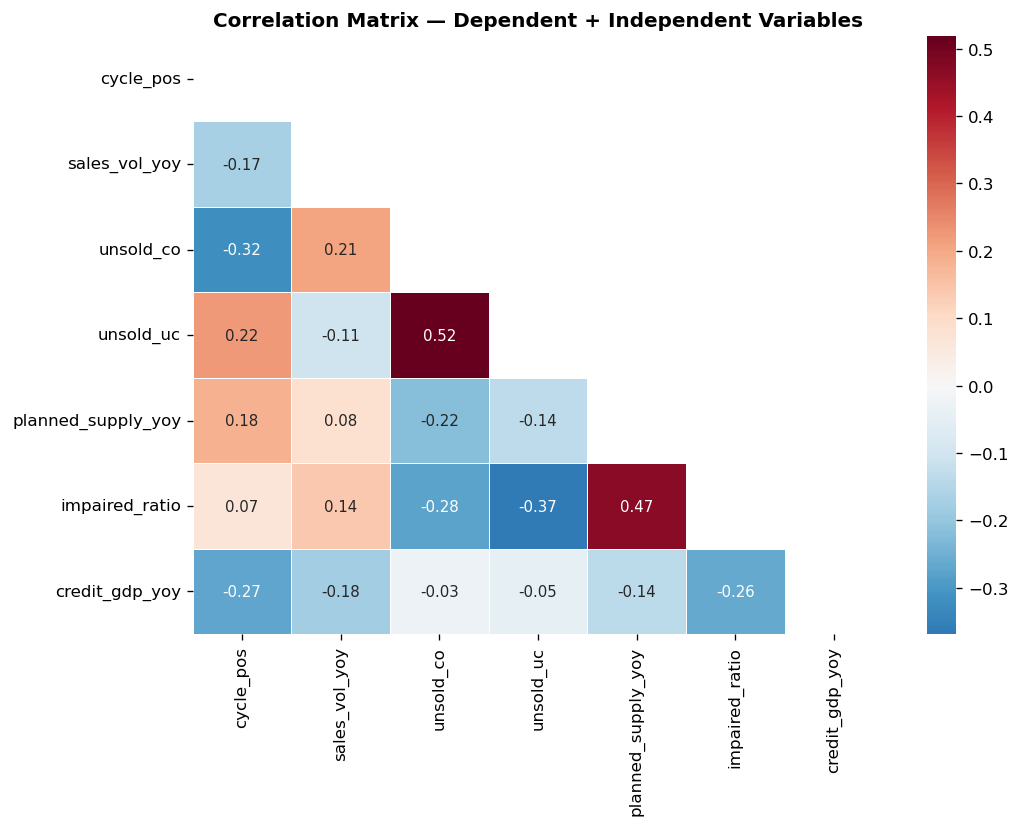

In [7]:
# ── correlation heatmap of all variables ──────────────────────────────────────
corr_cols = ['cycle_pos'] + indep_cols
corr = df_model[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Dependent + Independent Variables', fontweight='bold')
plt.tight_layout()
plt.savefig(PROP_DATA.replace('property data','Code') + r'\hcr_03_correlation.png',
            bbox_inches='tight')
plt.show()

---
## 5. Logistic Regression

**Specification:**

$$\ln\!\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1\,\Delta\text{sales\_yoy} + \beta_2\,\text{unsold\_co} + \beta_3\,\text{unsold\_uc} + \beta_4\,\Delta\text{supply\_yoy} + \beta_5\,\text{impaired\_ratio} + \beta_6\,\Delta\text{credit\_gdp\_yoy} + \varepsilon$$

where $p = P(\text{cycle\_pos} = 1)$ and $\Delta$ denotes YoY % growth.

All inputs standardised (z-score) for direct coefficient comparison.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_raw = df_model[indep_cols].values
X_scaled = scaler.fit_transform(X_raw)
X_df = pd.DataFrame(X_scaled, columns=indep_cols)

y = df_model['cycle_pos'].values

X_const = sm.add_constant(X_df)

logit_model = sm.Logit(y, X_const)
result = logit_model.fit(method='bfgs', maxiter=500, disp=True)
print(result.summary2())

Optimization terminated successfully.
         Current function value: 0.408114
         Iterations: 29
         Function evaluations: 30
         Gradient evaluations: 30
                          Results: Logit
Model:               Logit            Pseudo R-squared: 0.387     
Dependent Variable:  y                AIC:              88.2768   
Date:                2026-06-14 22:03 BIC:              105.8528  
No. Observations:    91               Log-Likelihood:   -37.138   
Df Model:            6                LL-Null:          -60.631   
Df Residuals:        84               LLR p-value:      1.8833e-08
Converged:           1.0000           Scale:            1.0000    
Method:              MLE                                          
------------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
------------------------------------------------------------------
const               1.0216   0.3707  2.7562 0.0058

In [9]:
# ── Odds Ratios ────────────────────────────────────────────────────────────────
params = result.params
conf   = result.conf_int()
conf.columns = ['CI_lower', 'CI_upper']

or_df = pd.concat([
    params.rename('coef'),
    np.exp(params).rename('OR'),
    np.exp(conf['CI_lower']).rename('OR_lower_95'),
    np.exp(conf['CI_upper']).rename('OR_upper_95'),
    result.pvalues.rename('p_value'),
], axis=1).round(4)

or_df['significance'] = or_df['p_value'].apply(
    lambda p: '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else '')))

print('\nOdds Ratios (standardised inputs):')
print(or_df.to_string())


Odds Ratios (standardised inputs):
                      coef      OR  OR_lower_95  OR_upper_95  p_value significance
const               1.0216  2.7777       1.3433       5.7437   0.0058          ***
sales_vol_yoy      -0.0117  0.9884       0.5382       1.8152   0.9699             
unsold_co          -2.2431  0.1061       0.0348       0.3237   0.0001          ***
unsold_uc           1.8993  6.6812       2.5101      17.7834   0.0001          ***
planned_supply_yoy  0.4874  1.6281       0.8149       3.2527   0.1675             
impaired_ratio      0.2542  1.2894       0.5453       3.0489   0.5627             
credit_gdp_yoy     -0.9427  0.3896       0.1998       0.7597   0.0057          ***


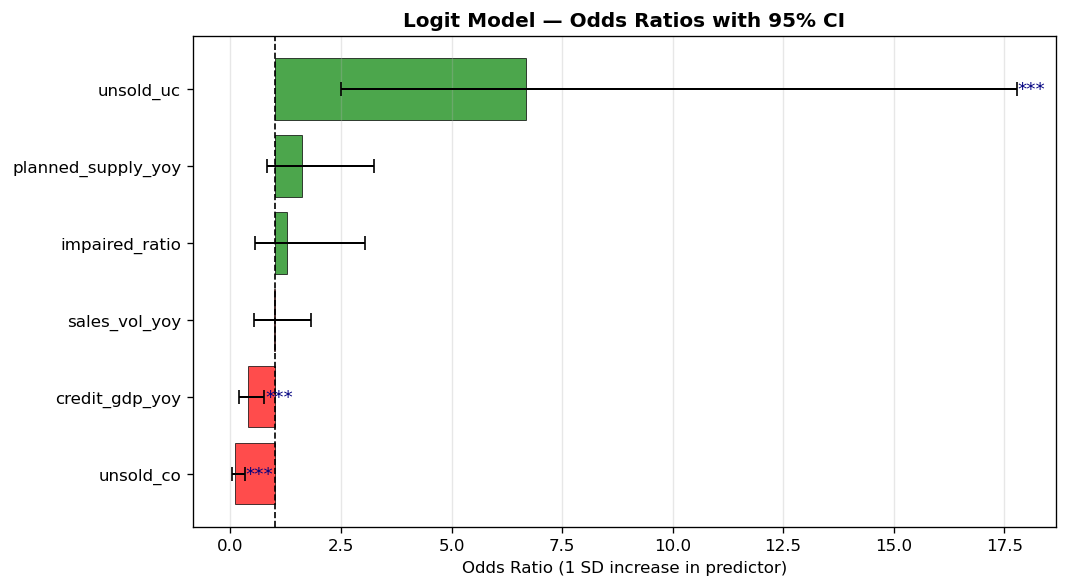

In [10]:
# ── Forest / coefficient plot ─────────────────────────────────────────────────
plot_df = or_df.drop(index='const').copy()
plot_df = plot_df.sort_values('OR')

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['green' if OR > 1 else 'red' for OR in plot_df['OR']]
ax.barh(plot_df.index, plot_df['OR'] - 1, left=1,
        color=colors, alpha=0.7, edgecolor='black', linewidth=0.6)
ax.errorbar(plot_df['OR'], range(len(plot_df)),
            xerr=[plot_df['OR'] - plot_df['OR_lower_95'],
                  plot_df['OR_upper_95'] - plot_df['OR']],
            fmt='none', color='black', capsize=4, linewidth=1.2)
ax.axvline(1, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Odds Ratio (1 SD increase in predictor)')
ax.set_title('Logit Model — Odds Ratios with 95% CI', fontweight='bold')
# annotate significance
for i, (idx, row) in enumerate(plot_df.iterrows()):
    ax.text(row['OR_upper_95'] + 0.02, i, row['significance'],
            va='center', fontsize=11, color='navy')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(PROP_DATA.replace('property data','Code') + r'\hcr_04_odds_ratios.png',
            bbox_inches='tight')
plt.show()

---
## 6. Regression Diagnostics

### 6a. Goodness-of-Fit Metrics

In [11]:
# ── Goodness-of-fit summary ────────────────────────────────────────────────────
n         = len(y)
k         = len(params) - 1  # excluding intercept
ll_full   = result.llf
ll_null   = result.llnull
mcfadden  = 1 - ll_full / ll_null
cox_snell = 1 - np.exp(-2 / n * (ll_full - ll_null))
nagelkerke = cox_snell / (1 - np.exp(2 / n * ll_null))
aic = result.aic
bic = result.bic
lr_stat   = -2 * (ll_null - ll_full)
lr_pval   = stats.chi2.sf(lr_stat, df=k)

gof = pd.Series({
    'N (observations)'       : n,
    'Log-likelihood (full)'  : round(ll_full, 4),
    'Log-likelihood (null)'  : round(ll_null, 4),
    'McFadden Pseudo-R²'     : round(mcfadden, 4),
    'Cox-Snell R²'           : round(cox_snell, 4),
    'Nagelkerke R²'          : round(nagelkerke, 4),
    'AIC'                    : round(aic, 2),
    'BIC'                    : round(bic, 2),
    'LR statistic'           : round(lr_stat, 4),
    'LR p-value'             : f'{lr_pval:.4e}',
})
print('=== Goodness-of-Fit Metrics ===')
print(gof.to_string())
print()
print('Benchmark: McFadden > 0.20 = acceptable; > 0.40 = excellent')

=== Goodness-of-Fit Metrics ===
N (observations)                 91
Log-likelihood (full)      -37.1384
Log-likelihood (null)      -60.6313
McFadden Pseudo-R²           0.3875
Cox-Snell R²                 0.4033
Nagelkerke R²                0.5478
AIC                           88.28
BIC                          105.85
LR statistic                46.9859
LR p-value               1.8833e-08

Benchmark: McFadden > 0.20 = acceptable; > 0.40 = excellent


### 6b. Hosmer-Lemeshow Test

In [12]:
def hosmer_lemeshow_test(y_true, y_pred_prob, g=10):
    """
    Hosmer-Lemeshow goodness-of-fit test.
    Null hypothesis: the model fits the data well.
    p-value > 0.05 -> fail to reject -> adequate fit.
    """
    df_hl = pd.DataFrame({'prob': y_pred_prob, 'obs': y_true})
    df_hl['decile'] = pd.qcut(df_hl['prob'], q=g, labels=False, duplicates='drop')

    grouped = df_hl.groupby('decile').agg(
        obs_1=('obs', 'sum'),
        n=('obs', 'count'),
        mean_prob=('prob', 'mean')
    ).reset_index()
    grouped['exp_1'] = grouped['n'] * grouped['mean_prob']
    grouped['obs_0'] = grouped['n'] - grouped['obs_1']
    grouped['exp_0'] = grouped['n'] - grouped['exp_1']

    hl_stat = (
        ((grouped['obs_1'] - grouped['exp_1'])**2 / grouped['exp_1']).sum() +
        ((grouped['obs_0'] - grouped['exp_0'])**2 / grouped['exp_0']).sum()
    )
    p_val = stats.chi2.sf(hl_stat, df=g - 2)
    return hl_stat, p_val, grouped

y_pred_prob = result.predict(X_const)
hl_stat, hl_p, hl_table = hosmer_lemeshow_test(y, y_pred_prob)

print('=== Hosmer-Lemeshow Test (g=10 groups) ===')
print(f'  H-L Chi² statistic : {hl_stat:.4f}')
print(f'  p-value            : {hl_p:.4f}')
print(f'  df                 : 8')
print()
if hl_p > 0.05:
    print('  Result: FAIL to reject H0 -> model fit is adequate (p > 0.05)')
else:
    print('  Result: REJECT H0 -> evidence of poor model fit (p <= 0.05)')
print()
print('Group table:')
print(hl_table[['decile','n','obs_1','exp_1','obs_0','exp_0']].round(2).to_string(index=False))

=== Hosmer-Lemeshow Test (g=10 groups) ===
  H-L Chi² statistic : 33.8594
  p-value            : 0.0000
  df                 : 8

  Result: REJECT H0 -> evidence of poor model fit (p <= 0.05)

Group table:
 decile  n  obs_1  exp_1  obs_0  exp_0
      0 10      1   0.85      9   9.15
      1  9      1   1.69      8   7.31
      2  9      2   2.43      7   6.57
      3  9      5   4.84      4   4.16
      4  9      5   6.17      4   2.83
      5  9      7   6.77      2   2.23
      6  9      9   7.31      0   1.69
      7  9      9   8.13      0   0.87
      8  9      9   8.84      0   0.16
      9  9      8   8.97      1   0.03


### 6c. Classification Performance

=== Classification Report (threshold = 0.5) ===
                 precision    recall  f1-score   support

Below Trend (0)       0.83      0.71      0.77        35
Above Trend (1)       0.84      0.91      0.87        56

       accuracy                           0.84        91
      macro avg       0.83      0.81      0.82        91
   weighted avg       0.84      0.84      0.83        91



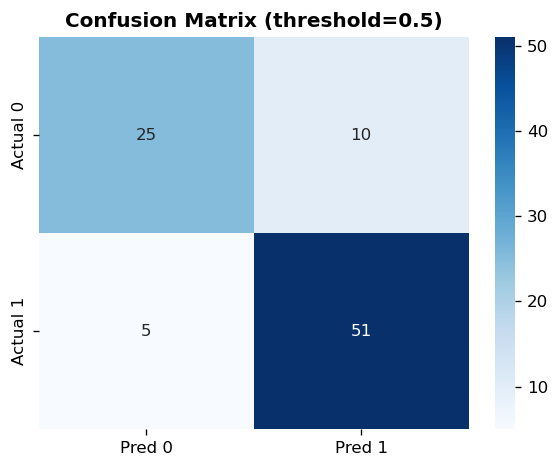

In [13]:
# ── classification at 0.5 threshold ───────────────────────────────────────────
y_pred_class = (y_pred_prob >= 0.5).astype(int)

print('=== Classification Report (threshold = 0.5) ===')
print(classification_report(y, y_pred_class,
                             target_names=['Below Trend (0)', 'Above Trend (1)']))

cm = confusion_matrix(y, y_pred_class)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax.set_title('Confusion Matrix (threshold=0.5)', fontweight='bold')
plt.tight_layout()
plt.savefig(PROP_DATA.replace('property data','Code') + r'\hcr_05_confusion_matrix.png',
            bbox_inches='tight')
plt.show()

### 6d. ROC Curve & AUC

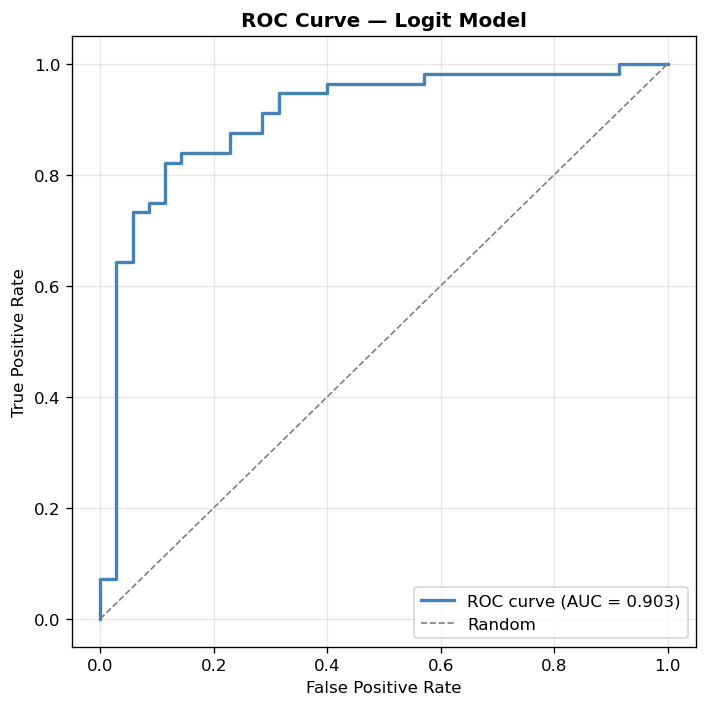

AUC = 0.9031
Benchmark: AUC > 0.70 = acceptable; > 0.80 = good; > 0.90 = excellent


In [14]:
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'ROC curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logit Model', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROP_DATA.replace('property data','Code') + r'\hcr_06_roc_curve.png',
            bbox_inches='tight')
plt.show()

print(f'AUC = {roc_auc:.4f}')
print('Benchmark: AUC > 0.70 = acceptable; > 0.80 = good; > 0.90 = excellent')

### 6e. Variance Inflation Factor (Multicollinearity)

=== Variance Inflation Factor (VIF) ===
          variable   VIF    flag
     sales_vol_yoy 1.181 OK (<5)
         unsold_co 1.590 OK (<5)
         unsold_uc 1.610 OK (<5)
planned_supply_yoy 1.318 OK (<5)
    impaired_ratio 1.579 OK (<5)
    credit_gdp_yoy 1.132 OK (<5)

Rule of thumb: VIF > 10 = severe multicollinearity; 5-10 = moderate


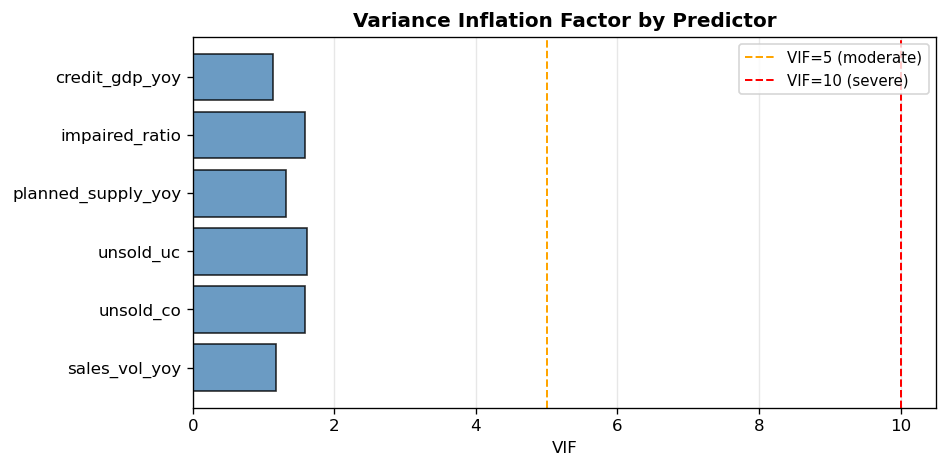

In [15]:
vif_data = pd.DataFrame()
vif_data['variable'] = indep_cols
vif_data['VIF'] = [
    variance_inflation_factor(X_df.values, i)
    for i in range(X_df.shape[1])
]
vif_data['VIF'] = vif_data['VIF'].round(3)
vif_data['flag'] = vif_data['VIF'].apply(
    lambda v: 'HIGH (>10)' if v > 10 else ('MODERATE (5-10)' if v > 5 else 'OK (<5)'))

print('=== Variance Inflation Factor (VIF) ===')
print(vif_data.to_string(index=False))
print()
print('Rule of thumb: VIF > 10 = severe multicollinearity; 5-10 = moderate')

# bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors_vif = ['red' if v > 10 else ('orange' if v > 5 else 'steelblue')
              for v in vif_data['VIF']]
ax.barh(vif_data['variable'], vif_data['VIF'], color=colors_vif, edgecolor='black', alpha=0.8)
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.2, label='VIF=5 (moderate)')
ax.axvline(10, color='red',    linestyle='--', linewidth=1.2, label='VIF=10 (severe)')
ax.set_xlabel('VIF')
ax.set_title('Variance Inflation Factor by Predictor', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(PROP_DATA.replace('property data','Code') + r'\hcr_07_vif.png',
            bbox_inches='tight')
plt.show()

### 6f. Predicted Probability Time-Series vs Actual Cycle

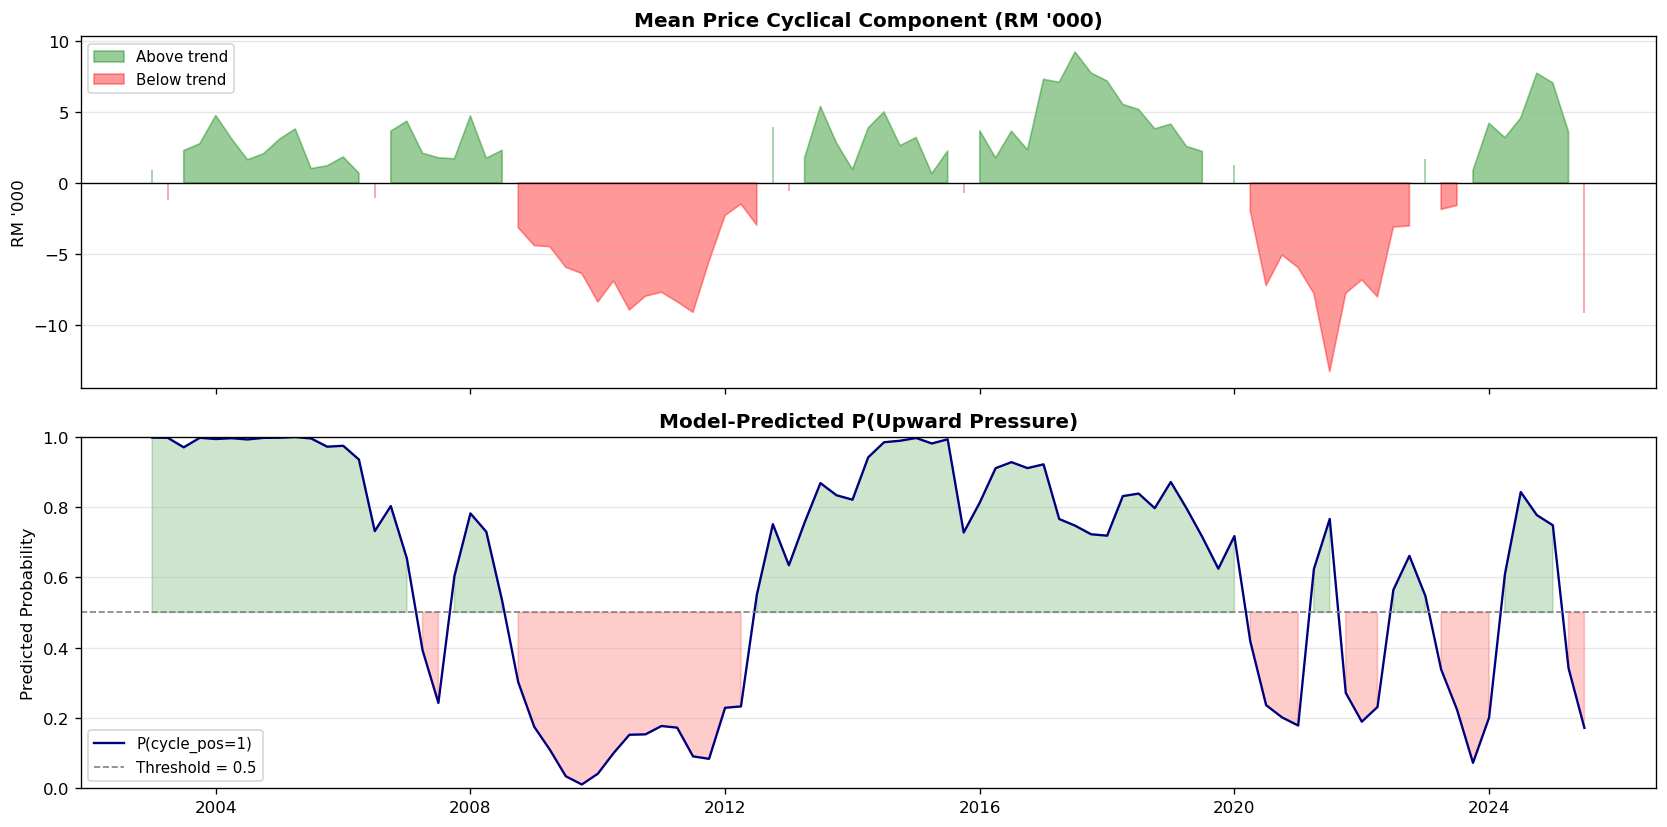

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].fill_between(df_model['date'], df_model['mp_cycle'] / 1_000, 0,
                     where=(df_model['mp_cycle'] > 0), alpha=0.4, color='green',
                     label='Above trend')
axes[0].fill_between(df_model['date'], df_model['mp_cycle'] / 1_000, 0,
                     where=(df_model['mp_cycle'] <= 0), alpha=0.4, color='red',
                     label='Below trend')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title("Mean Price Cyclical Component (RM '000)", fontweight='bold')
axes[0].set_ylabel("RM '000")
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

axes[1].plot(df_model['date'], y_pred_prob, color='navy', linewidth=1.4,
             label='P(cycle_pos=1)')
axes[1].axhline(0.5, color='gray', linewidth=1, linestyle='--', label='Threshold = 0.5')
axes[1].fill_between(df_model['date'], y_pred_prob, 0.5,
                     where=(y_pred_prob >= 0.5), alpha=0.2, color='green')
axes[1].fill_between(df_model['date'], y_pred_prob, 0.5,
                     where=(y_pred_prob < 0.5), alpha=0.2, color='red')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('Predicted Probability')
axes[1].set_title('Model-Predicted P(Upward Pressure)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(PROP_DATA.replace('property data', 'Code') + r'\hcr_08_predicted_vs_actual.png',
            bbox_inches='tight')
plt.show()

### 6g. Deviance Residuals

Deviance residuals > |2|: 2 observations


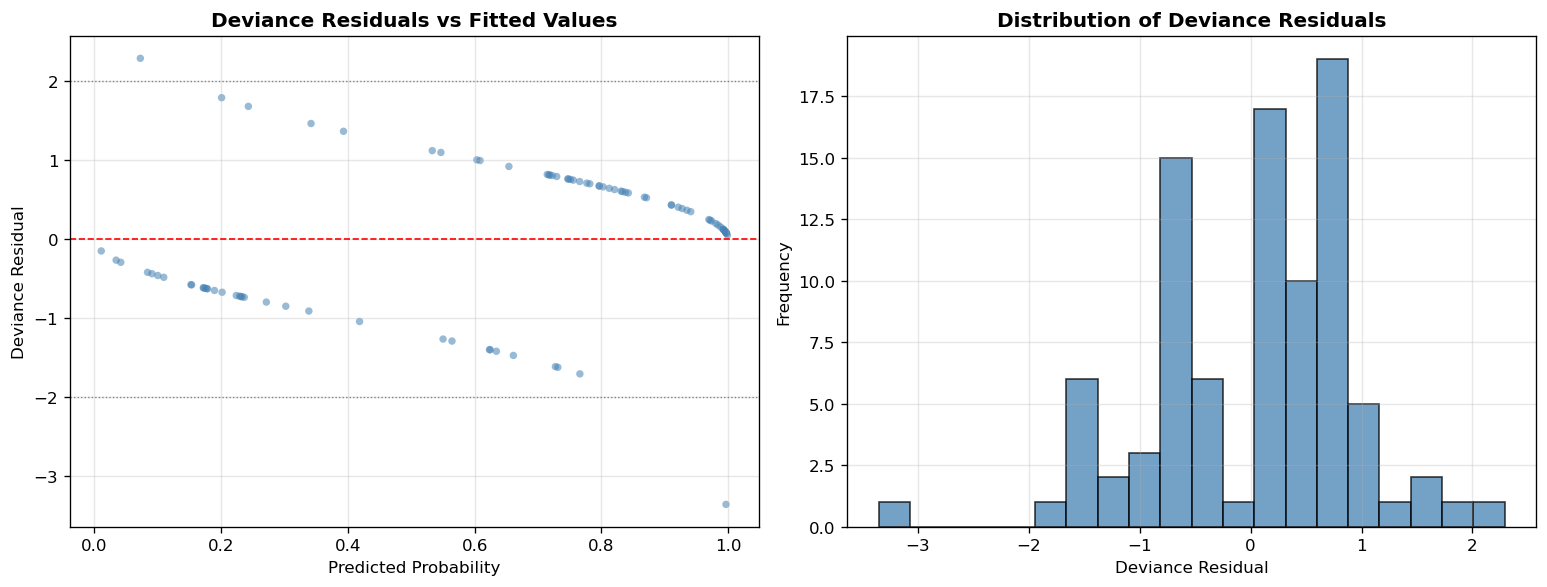

In [17]:
# deviance residuals
eps = 1e-10
p_clip = np.clip(y_pred_prob, eps, 1 - eps)
dev_resid = np.sign(y - p_clip) * np.sqrt(
    -2 * (y * np.log(p_clip) + (1 - y) * np.log(1 - p_clip))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_pred_prob, dev_resid, alpha=0.55, s=20, color='steelblue', edgecolors='none')
axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].axhline(2, color='gray', linewidth=0.8, linestyle=':')
axes[0].axhline(-2, color='gray', linewidth=0.8, linestyle=':')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Deviance Residual')
axes[0].set_title('Deviance Residuals vs Fitted Values', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].hist(dev_resid, bins=20, color='steelblue', edgecolor='black', alpha=0.75)
axes[1].set_xlabel('Deviance Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Deviance Residuals', fontweight='bold')
axes[1].grid(alpha=0.3)

print(f'Deviance residuals > |2|: {(np.abs(dev_resid) > 2).sum()} observations')

plt.tight_layout()
plt.savefig(PROP_DATA.replace('property data','Code') + r'\hcr_09_deviance_residuals.png',
            bbox_inches='tight')
plt.show()

---
## 7. Summary

Interpret the full model here after running.

In [18]:
print('===== HCR LOGIT MODEL — COMPLETE DIAGNOSTICS SUMMARY =====')
print(f'  Sample            : {df_model.date.min().date()} to {df_model.date.max().date()}')
print(f'  N                 : {n}')
print(f'  Positive class    : {y.sum()} ({y.mean()*100:.1f}%)')
print(f'  McFadden R²       : {mcfadden:.4f}')
print(f'  Nagelkerke R²     : {nagelkerke:.4f}')
print(f'  AUC               : {roc_auc:.4f}')
print(f'  Hosmer-Lemeshow p : {hl_p:.4f}')
print(f'  AIC               : {aic:.2f}')
print(f'  BIC               : {bic:.2f}')
print()
print('Significant predictors (p < 0.05):')
sig = or_df[(or_df['p_value'] < 0.05) & (or_df.index != 'const')]
print(sig[['coef','OR','p_value','significance']].to_string())
print()
print('Multicollinearity flags (VIF > 5):')
print(vif_data[vif_data['VIF'] > 5].to_string(index=False))

===== HCR LOGIT MODEL — COMPLETE DIAGNOSTICS SUMMARY =====
  Sample            : 2003-01-01 to 2025-07-01
  N                 : 91
  Positive class    : 56 (61.5%)
  McFadden R²       : 0.3875
  Nagelkerke R²     : 0.5478
  AUC               : 0.9031
  Hosmer-Lemeshow p : 0.0000
  AIC               : 88.28
  BIC               : 105.85

Significant predictors (p < 0.05):
                  coef      OR  p_value significance
unsold_co      -2.2431  0.1061   0.0001          ***
unsold_uc       1.8993  6.6812   0.0001          ***
credit_gdp_yoy -0.9427  0.3896   0.0057          ***

Multicollinearity flags (VIF > 5):
Empty DataFrame
Columns: [variable, VIF, flag]
Index: []
